# Gradiente Descendiente en la práctica

### Escalamiento de Características (Feature Scaling)

Al pasar de la Regresión Lineal Simple a la Regresión Lineal Múltiple, nos enfrentamos a un reto común en los datasets del mundo real: las características de entrada vienen expresadas en unidades y magnitudes muy distintas.

Por ejemplo, al predecir el precio de un inmueble o evaluar el riesgo de salud de un paciente:
- El Tamaño ($x_1$) puede variar entre $50$ y $300\text{ m}^2$.
- La Edad ($x_2$) puede variar entre $1$ y $50\text{ años}$.
- Las Habitaciones ($x_3$) varían entre $1$ y $5$.

Cuando las variables de entrada presentan rangos numéricos dispares, el Descenso del Gradiente se vuelve ineficiente, lento e inestable. Para solucionar esto, aplicamos una técnica llamada Escalamiento de Características (Feature Scaling).

El Problema: Superficies de Costo Deformadas

Cuando una característica $x_1$ toma valores muy grandes (ej. $300$) y otra $x_2$ toma valores muy pequeños (ej. $2$), un pequeño cambio en el peso $w_1$ provoca un impacto gigantesco en la predicción final $f(\mathbf{x})$, mientras que un cambio en $w_2$ produce un efecto casi imperceptible.

¿Qué ocurre en la función de costo $J(\mathbf{w}, b)$?

- Sin Escalamiento: La función de costo adquiere una forma elíptica o de "tazón alargado/ovalado".
- Efecto en el Gradiente: Al calcular las derivadas parciales, los gradientes rebotan zizagueando de un lado a otro sobre las paredes empinadas de la elipse, requiriendo un learning rate ($\alpha$) extremadamente pequeño para no divergir.
- Con Escalamiento: La función de costo se transforma en un "tazón esférico/circular" perfecto, permitiendo que el Descenso del Gradiente apunte directamente hacia el mínimo global en línea recta.

Ejemplo Gráfico

Para visualizar esto directamente, lo podremos visualizar en mapas de contorno (contour plots) comparativos con el siguiente bloque de código:

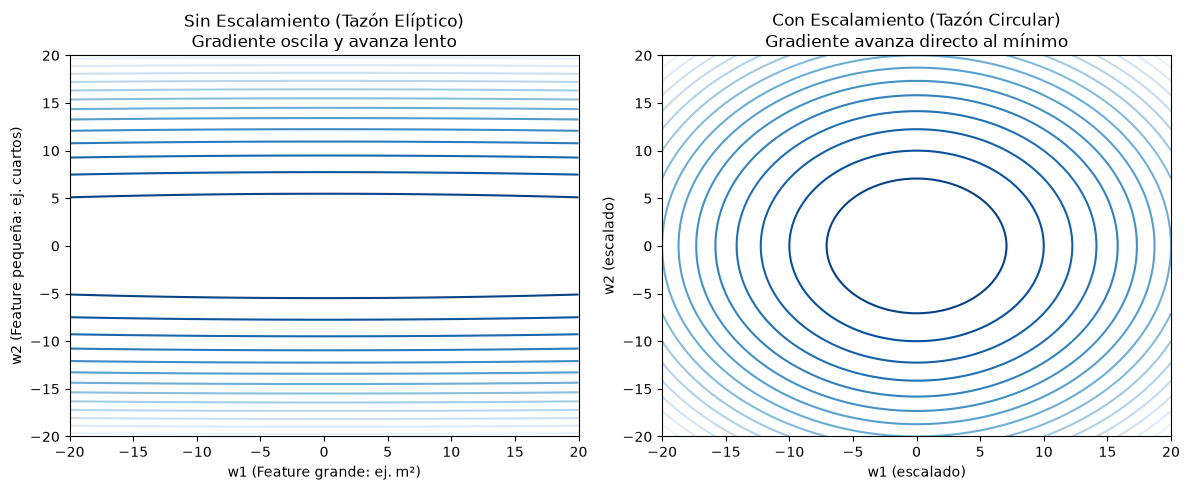

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Crear una malla de pesos w1 y w2
w1 = np.linspace(-20, 20, 100)
w2 = np.linspace(-20, 20, 100)
W1, W2 = np.meshgrid(w1, w2)

# Costo sin escalar (Elíptico / Alargado) -> Una variable domina el costo
J_unscaled = 0.05 * (W1**2) + 5.0 * (W2**2)

# Costo con escalamiento (Circular / Simétrico) -> Escalas equilibradas
J_scaled = 1.0 * (W1**2) + 1.0 * (W2**2)

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Sin escalamiento
ax1.contour(W1, W2, J_unscaled, levels=15, cmap='Blues_r')
ax1.set_title("Sin Escalamiento (Tazón Elíptico)\nGradiente oscila y avanza lento")
ax1.set_xlabel("w1 (Feature grande: ej. m²)")
ax1.set_ylabel("w2 (Feature pequeña: ej. cuartos)")

# Plot 2: Con escalamiento
ax2.contour(W1, W2, J_scaled, levels=15, cmap='Blues_r')
ax2.set_title("Con Escalamiento (Tazón Circular)\nGradiente avanza directo al mínimo")
ax2.set_xlabel("w1 (escalado)")
ax2.set_ylabel("w2 (escalado)")

plt.tight_layout()
plt.show()

Sin Feature Scaling: Como los rangos son tan drásticamente distintos, si los ejes tienen la misma escala visual, la nube de puntos queda completamente aplastada como una línea delgada o un "hilo" en el plano.

Con Feature Scaling: La nube de puntos se expande y se centra en el origen $(0,0)$, distribuyéndose de manera uniforme y proporcional en ambas direcciones.

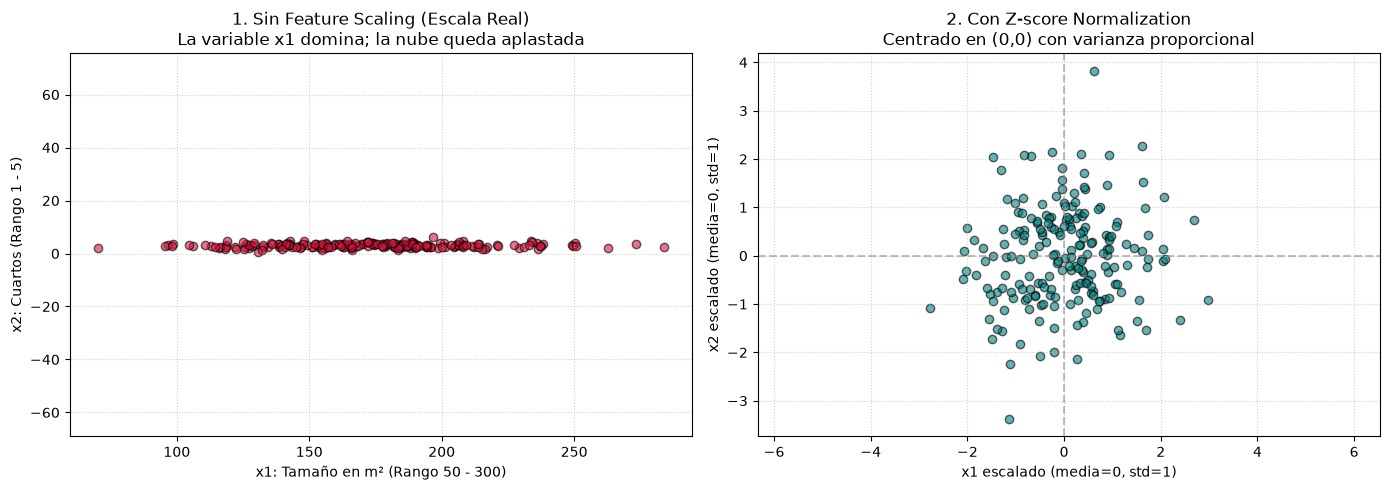

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generar datos sintéticos con escalas muy dispares
np.random.seed(42)
m = 200

# Feature 1: Tamaño de casa en m² (Rango: ~50 a 300)
x1 = np.random.normal(loc=175, scale=40, size=m)

# Feature 2: Número de habitaciones (Rango: ~1 a 5)
x2 = np.random.normal(loc=3, scale=0.8, size=m)

X_raw = np.column_stack((x1, x2))

# 2. Aplicar Normalización Z-score
mu = np.mean(X_raw, axis=0)
sigma = np.std(X_raw, axis=0)
X_norm = (X_raw - mu) / sigma

# 3. Graficar comparación espacio de características
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Datos Originales (Sin Scaling) ---
ax1.scatter(X_raw[:, 0], X_raw[:, 1], color='crimson', alpha=0.6, edgecolors='k')
ax1.set_title("1. Sin Feature Scaling (Escala Real)\nLa variable x1 domina; la nube queda aplastada")
ax1.set_xlabel("x1: Tamaño en m² (Rango 50 - 300)")
ax1.set_ylabel("x2: Cuartos (Rango 1 - 5)")
# Forzar escala igualitaria para evidenciar la desproporción real
ax1.set_aspect('equal', adjustable='datalim')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Datos Normalizados (Con Z-score) ---
ax2.scatter(X_norm[:, 0], X_norm[:, 1], color='teal', alpha=0.6, edgecolors='k')
ax2.set_title("2. Con Z-score Normalization\nCentrado en (0,0) con varianza proporcional")
ax2.set_xlabel("x1 escalado (media=0, std=1)")
ax2.set_ylabel("x2 escalado (media=0, std=1)")
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_aspect('equal', adjustable='datalim')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

¿Cómo se Resuelve? Métodos de Escalamiento

Existen dos métodos principales para transformar el rango de las características a una escala uniforme.

Método 1: Normalización Z-Score (Standardization) (Recomendado)

Transforma las características para que tengan una media ($\mu = 0$) y una desviación estándar ($\sigma = 1$).

Para cada valor de una característica $j$ en el ejemplo $i$:

$$x_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$

Donde:

$\mu_j = \frac{1}{m} \sum_{i=1}^{m} x_j^{(i)}$ (Media de la característica $j$)

$\sigma_j = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (x_j^{(i)} - \mu_j)^2}$ (Desviación estándar de la característica $j$)

Método 2: Escalamiento Min-Max (Rescaling)

Ajusta todos los valores estrictamente dentro del rango de $[0, 1]$ o $[-1, 1]$:

$$x_j^{(i)} = \frac{x_j^{(i)} - \text{min}(x_j)}{\text{max}(x_j) - \text{min}(x_j)}$$

Implementación vectorizada de la normalización Z-score:

In [4]:
import numpy as np

def zscore_normalize_features(X):
    """
    Calcula la normalización Z-score sobre una matriz X de (m, n).
    
    Args:
      X (ndarray (m,n)): Datos de entrada (m ejemplos, n features)
      
    Returns:
      X_norm (ndarray (m,n)): Matriz de entrada normalizada
      mu (ndarray (n,)):     Media de cada característica
      sigma (ndarray (n,)):  Desviación estándar de cada característica
    """
    # 1. Calcular la media de cada columna (axis=0)
    mu = np.mean(X, axis=0)
    
    # 2. Calcular la desviación estándar de cada columna (axis=0)
    sigma = np.std(X, axis=0)
    
    # 3. Aplicar la fórmula usando Broadcasting de NumPy
    X_norm = (X - mu) / sigma
    
    return X_norm, mu, sigma